# Product Category Performance, Revenue Drivers & Review Ratings
**Objective**: Analyze category sales volume, revenue concentration, customer review ratings, and physical dimensions.

C:\Users\Shubham Meena\AppData\Local\Temp\ipykernel_46576\3255196785.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_perf, x='gmv', y='category_name_english', palette='crest')


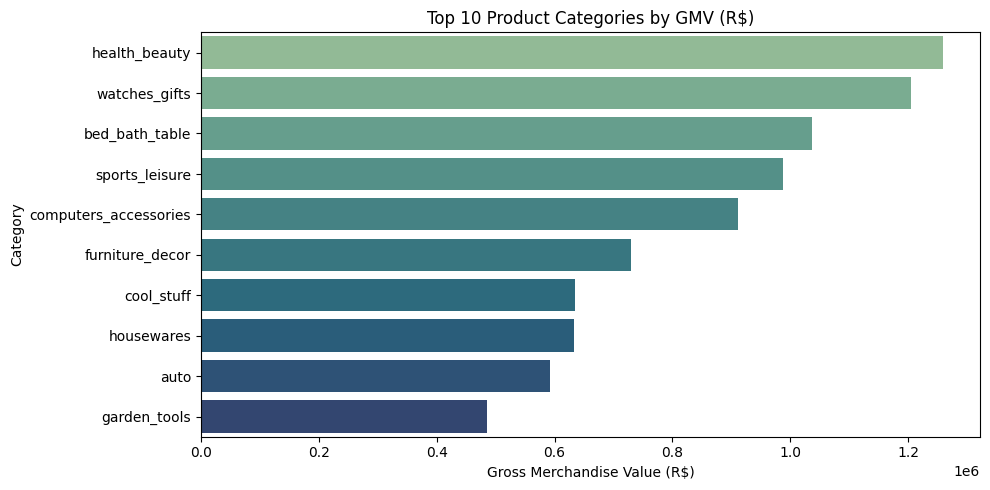

,category_name_english,gmv,items
43,health_beauty,1258681.34,9670
73,watches_gifts,1205005.68,5991
7,bed_bath_table,1036988.68,11115
67,sports_leisure,988048.97,8641
15,computers_accessories,911954.32,7827
39,furniture_decor,729762.49,8334
20,cool_stuff,635290.85,3796
49,housewares,632248.66,6964
5,auto,592720.11,4235
42,garden_tools,485256.46,4347


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

proc_dir = r'../data/processed'
items = pd.read_csv(os.path.join(proc_dir, 'clean_order_items.csv'))
products = pd.read_csv(os.path.join(proc_dir, 'clean_products.csv'))

merged = items.merge(products[['product_id', 'category_name_english']], on='product_id')
cat_perf = merged.groupby('category_name_english').agg(
    gmv=('price', 'sum'),
    items=('order_item_id', 'count')
).reset_index().sort_values('gmv', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=cat_perf, x='gmv', y='category_name_english', palette='crest')
plt.title('Top 10 Product Categories by GMV (R$)')
plt.xlabel('Gross Merchandise Value (R$)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()
cat_perf